In [615]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [616]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

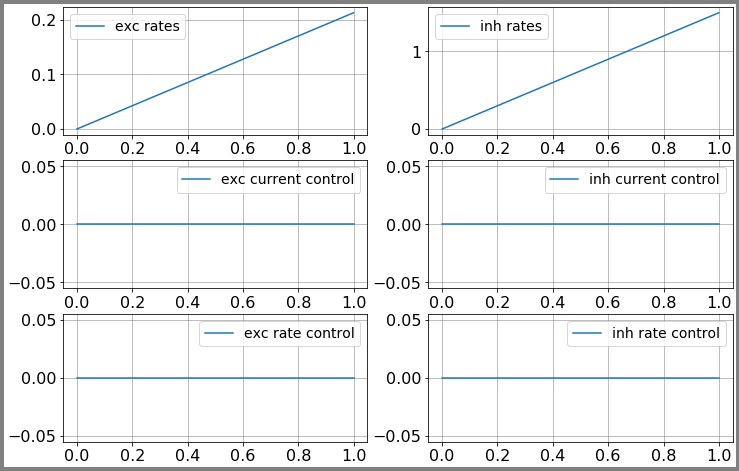

[[0. 0.]]


In [617]:
aln = RateModel()

aln.params.dt = 1.
aln.params['duration'] = 1.
control0 = aln.getZeroControl()
target = aln.getZeroTarget()
#control0 = step_control(maxI_ = 1.)

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.sigmae_ext = 0.

#aln.params.c_gl = 1.
#aln.params.Ke_gl = 1.
#aln.params.tau_se = 1.
#aln.params.Jee_max = 1.
#aln.params.C = 1.
#aln.params.gL = 1.
#aln.params.cee = 1.
#aln.params.Ke = 1.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroFullState()
plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

for i in range(len(state_vars)):
    state[:,i,:] = aln.state[state_vars[i]]

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]
        
high_state_vars[5] = 0.
high_state_vars[0] = 0.


print(aln.state["mufe"])

In [239]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                    

In [240]:
tol = 1e-18

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

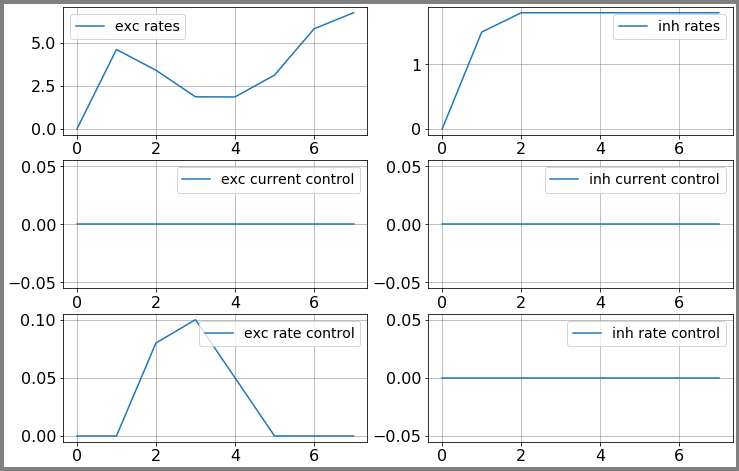

[[0.         0.         0.0457662  0.31135558 0.5210888  0.57778131
  0.56200626 0.55916241]]
[[0. 0. 0. 0. 0. 0. 0. 0.]]
[[4.63382818 3.42344868 1.87555221 1.7579045  2.27699536 3.70442828
  3.23764098 0.        ]]


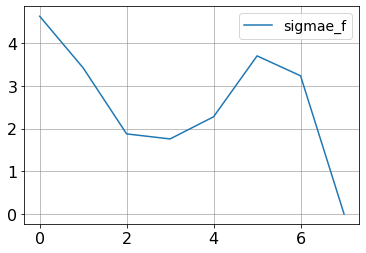

In [686]:
dur = 7.
dur_pre = 0.
dur_post = 0.
aln.params.duration = dur

control_ind = 2
control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
control0[0,control_ind,2] =  0.08
control0[0,control_ind,3] = 0.1
control0[0,control_ind,4] = 0.05
#control0[0,control_ind,:] = [0.08044293, 0.07931774, 0.05732154, 0.00748632, 0.07283936, 0.00502723, 0.00554333, 0.04001615]

setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)

#print(aln.state["rates_exc"])
# 0.28603878 0.75 3.20786163

target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,:]
target[0,1,:] = aln.rates_inh[0,:]

#plt.plot(aln.t, aln.state["seem"][0,:], label="seem")
#plt.plot(aln.t, aln.state["seev"][0,:], label="seev")
plt.plot(aln.t, aln.state["sigmae_f"][0,:], label="sigmae_f")
plt.legend()
#print(aln.state["rates_exc"])
#print(aln.state["mufe"])
print(aln.state["seem"])
print(aln.state["seev"])
print(aln.state["sigmae_f"])

In [687]:
cost.setParams(1., 1.0, 1.* 1e-2)
max_cntrl = 1.

setinitvars(high_state_vars)
max_it = 500
start_step = 1.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
#control1[0,0,5] = 0.11
control2 = bestControlA
#control2 = bestControlA_A2[:,:,:]

# "HS", "FR", "PR", "HZ"
cgv = "HS"

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = [control_ind], prec_variables_ = [0,1])

print("grad = ", grad[0,control_ind,:])

print("best control = ", bestControlA[0,control_ind,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.0011694607062876605

set cost params
RUN  0 , total integrated cost =  7.8886332290644985


ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:ro

error
error
error
error
error
error
error
error
error
error
error
error
RUN  1 , total integrated cost =  1.5211617280860918
error
error
error
error
error
RUN  2 , total integrated cost =  0.9093354884628615
error
error
error
error
RUN  3 , total integrated cost =  0.7938881001591837
error
error
error
error
RUN  4 , total integrated cost =  0.5770549162645933
error
error
error
error
RUN  5 , total integrated cost =  0.48052708889245527
error
error
error
error
RUN  6 , total integrated cost =  0.39080046034528193
error
error
error
RUN  7 , total integrated cost =  0.3361189965786879
RUN  8 , total integrated cost =  0.25996841131640525
error
error
RUN  9 , total integrated cost =  0.10090086702913717
RUN  10 , total integrated cost =  0.06415886576395785
error
RUN  11 , total integrated cost =  0.01789657882550953
error
error
RUN  12 , total integrated cost =  0.007475456074183114
error
RUN  13 , total integrated cost =  0.0012205348463035486
RUN  14 , total integrated cost =  0.0003709

RUN  150 , total integrated cost =  7.904330807883731e-11
RUN  151 , total integrated cost =  7.783071074890159e-11
RUN  152 , total integrated cost =  7.638809747229053e-11
RUN  153 , total integrated cost =  7.491007313816195e-11
RUN  154 , total integrated cost =  7.380287651318461e-11
RUN  155 , total integrated cost =  7.273338512864038e-11
RUN  156 , total integrated cost =  7.182202887466335e-11
RUN  157 , total integrated cost =  7.091002977261855e-11
RUN  158 , total integrated cost =  6.990127853798915e-11
RUN  159 , total integrated cost =  6.885160520387853e-11
RUN  160 , total integrated cost =  6.754922384414045e-11
RUN  161 , total integrated cost =  6.627333848068719e-11
RUN  162 , total integrated cost =  6.527918251744287e-11
RUN  163 , total integrated cost =  6.43514150287352e-11
RUN  164 , total integrated cost =  6.353525644415474e-11
RUN  165 , total integrated cost =  6.274234279232055e-11
RUN  166 , total integrated cost =  6.183471451429652e-11
RUN  167 , tota

RUN  300 , total integrated cost =  8.792563772357519e-12
RUN  301 , total integrated cost =  8.706327108842185e-12
RUN  302 , total integrated cost =  8.62095824761752e-12
RUN  303 , total integrated cost =  8.536448359330103e-12
RUN  304 , total integrated cost =  8.452788794910146e-12
RUN  305 , total integrated cost =  8.3699318799542e-12
RUN  306 , total integrated cost =  8.285075149236018e-12
RUN  307 , total integrated cost =  8.201173357779482e-12
RUN  308 , total integrated cost =  8.120771893752705e-12
RUN  309 , total integrated cost =  8.041177991692386e-12
RUN  310 , total integrated cost =  7.962383512605173e-12
RUN  311 , total integrated cost =  7.884380340880687e-12
RUN  312 , total integrated cost =  7.807160508019043e-12
RUN  313 , total integrated cost =  7.730716063493405e-12
RUN  314 , total integrated cost =  7.655039208882863e-12
RUN  315 , total integrated cost =  7.580122151744704e-12
RUN  316 , total integrated cost =  7.505957259343735e-12
RUN  317 , total 

RUN  465 , total integrated cost =  1.7284365013824973e-12
RUN  466 , total integrated cost =  1.7118495621995634e-12
RUN  467 , total integrated cost =  1.6954253413805402e-12
RUN  468 , total integrated cost =  1.679162240674526e-12
RUN  469 , total integrated cost =  1.663058673436523e-12
RUN  470 , total integrated cost =  1.6471130764750365e-12
RUN  471 , total integrated cost =  1.6312923991587333e-12
RUN  472 , total integrated cost =  1.6151502741366668e-12
RUN  473 , total integrated cost =  1.5990405657482322e-12
RUN  474 , total integrated cost =  1.5831213246932624e-12
RUN  475 , total integrated cost =  1.567480083026418e-12
RUN  476 , total integrated cost =  1.552442266124024e-12
RUN  477 , total integrated cost =  1.5372270101432675e-12
RUN  478 , total integrated cost =  1.5223825486420747e-12
RUN  479 , total integrated cost =  1.5075754923645815e-12
RUN  480 , total integrated cost =  1.4929281319301538e-12
RUN  481 , total integrated cost =  1.4785125671820854e-12
R

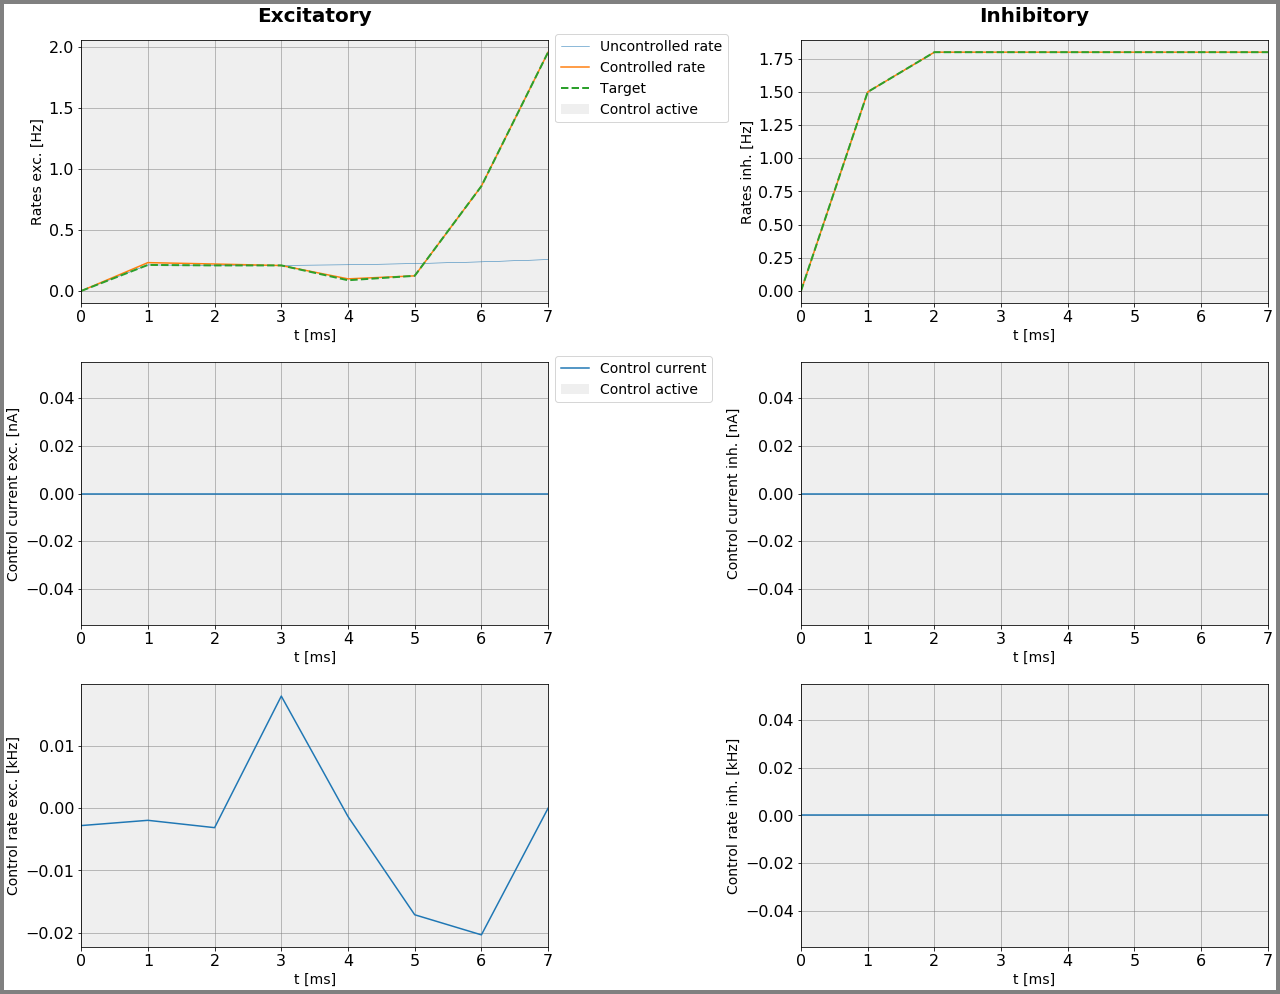

In [661]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

ValueError: x and y must have same first dimension, but have shapes (71,) and (8,)

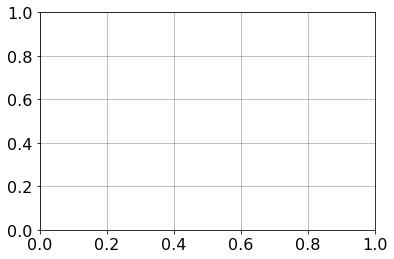

In [445]:
diff = control0 - bestControlA
#diff[0,2,-2:] = 0.

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [600]:
setinitvars(high_state_vars)
max_it = 100
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-8

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA_A2[:,:,:]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, control_variables_ = [control_ind])

ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!


RUN  0 , total integrated cost:  1.3246703178950352
RUN  1 , total integrated cost:  0.3015462169320281
error
error
error
error
error
error
error
error
error
RUN  2 , total integrated cost:  0.14389874224367644
error
error
error
error
error
error
error
error
error
error
error
error
error


ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:ro

error
RUN  3 , total integrated cost:  0.06907135772910582
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
RUN  4 , total integrated cost:  0.03732157450735422
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error


ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:ro

...

error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
RUN  97 , total integrated cost:  0.003234536456624534
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error


ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:ro

error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
RUN  98 , total integrated cost:  0.003218938528399621
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error


ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:ro

RUN  99 , total integrated cost:  0.0032049927400255415
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
RUN  100 , total integrated cost:  0.00319043303255717
Improved over  100  iterations by  100  percent.


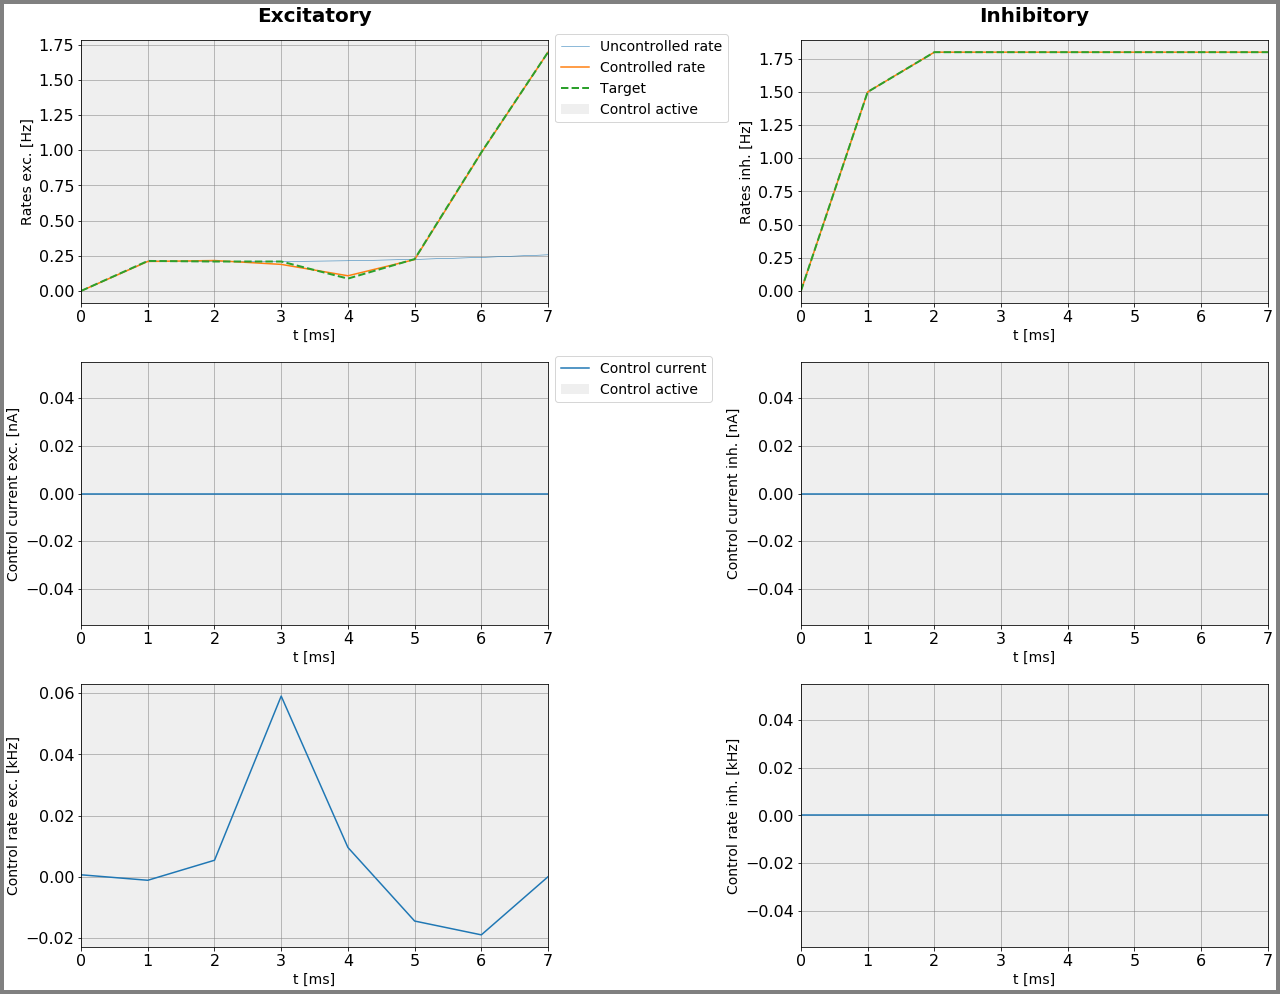

In [601]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

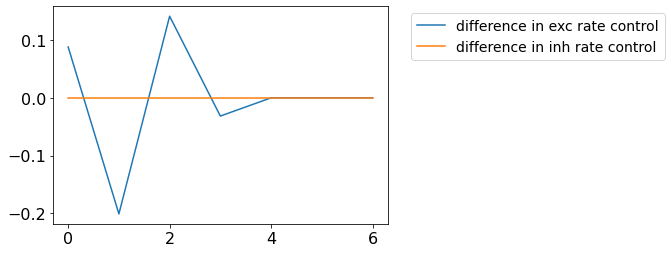

In [227]:
diff = control0 - bestControlA_A2
diff[0,2,-2:] = 0.

t = np.arange(0,dur+aln.params.dt, aln.params.dt)

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

-0.0004884455958080736


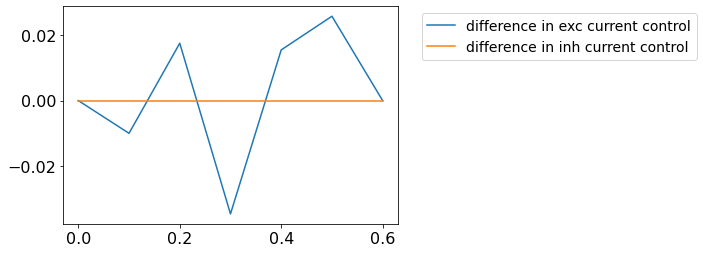

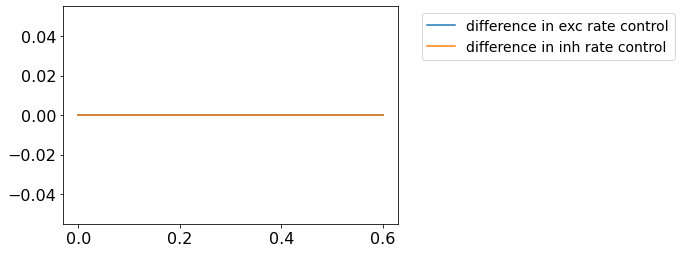

In [29]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

c_diff = costA_A2[6] - costA[3]
print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [97]:
print(12.*22.26 + 69.11 + 2.*191.1)
print(2.*191.1)

718.4300000000001
382.2
